In [1]:
from typing import Annotated, Final, Tuple, Literal, TypedDict
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.store.postgres import PostgresStore
from loadmodel import load_model, load_postgresconfig
from langgraph.graph.message import MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage,SystemMessage,AIMessage,ToolMessage
from langgraph import graph
from langgraph.runtime import Runtime
from loguru import logger

DB_DSN = load_postgresconfig()
# 初始化模型
model = load_model()

with PostgresStore.from_conn_string(DB_DSN) as store:
    # 1. 初始化数据库，创建长期记忆存储的表
    store.setup()
    # 2. 构建永久记忆数据
    # 2.1 定义永久记忆的命名空间
    USERS_NS: Final[Tuple[str]] = ("users",)
    PREFERENCES_KEY: Final[str] = "preferences"
    # 2.2 定义永久记忆的键值对
    namespace1 = (*USERS_NS, "Alice")
    namespace2 = (*USERS_NS, "Bob")
    namespace3 = (*USERS_NS, "Charlie")

    value1 = {
        "course": "Math",
        "sports": "跑步",
        "food": "鱼香肉丝"
    }
    value2 = {
        "course": "Physics",
        "sports": "篮球",
        "food": "红烧肉"
    }
    value3 = {
        "course": "Chemistry",
        "sports": "游泳",
        "food": "青椒肉丝"
    }

    # 3. 写入永久记忆数据
    store.put(namespace1, PREFERENCES_KEY, value1)
    store.put(namespace2, PREFERENCES_KEY, value2)
    store.put(namespace3, PREFERENCES_KEY, value3)

    for item in store.search(USERS_NS):
        print(item)


Item(namespace=['users', 'Charlie'], key='preferences', value={'food': '青椒肉丝', 'course': 'Chemistry', 'sports': '游泳'}, created_at='2026-08-20T12:17:53.525580+08:00', updated_at='2026-08-20T14:42:11.371083+08:00', score=None)
Item(namespace=['users', 'Bob'], key='preferences', value={'food': '红烧肉', 'course': 'Physics', 'sports': '篮球'}, created_at='2026-08-20T12:17:53.524898+08:00', updated_at='2026-08-20T14:42:11.370680+08:00', score=None)
Item(namespace=['users', 'Alice'], key='preferences', value={'food': '鱼香肉丝', 'course': 'Math', 'sports': '跑步'}, created_at='2026-08-20T12:17:53.521649+08:00', updated_at='2026-08-20T14:42:11.369031+08:00', score=None)


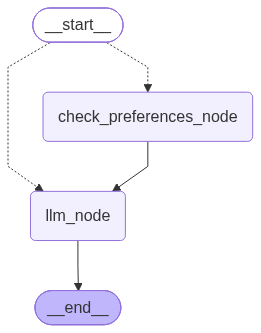

2026-08-20 14:44:11.104 | INFO     | __main__:router:18 - 直接执行大模型节点


基于你喜欢的**篮球**，以及你对**物理**和**红烧肉**（暗示可能喜欢享受美食或注重能量补充）的偏好，我为你量身定制了以下几类运动推荐。

这些运动不仅能提升你的篮球表现，还能满足你对身体力学的好奇心，同时帮你更好地代谢掉红烧肉的热量：

### 1. 核心与爆发力训练（直接提升篮球水平）
既然你喜欢篮球，那么增强核心力量和垂直弹跳是重中之重。
*   **推荐项目**：**CrossFit（混合健身）** 或 **HIIT（高强度间歇训练）**
*   **为什么适合你**：
    *   **篮球关联**：这些训练包含大量的跳跃、快速变向和核心稳定动作，能直接转化为球场上的突破速度和防守稳定性。
    *   **物理视角**：你可以把身体看作一个杠杆系统。在深蹲跳时，思考如何通过增加力臂和优化发力角度（$F=ma$）来获得最大的地面反作用力，这非常符合物理学思维。

### 2. 低冲击有氧（为了更安心地吃红烧肉）
红烧肉虽然美味，但脂肪和糖分含量较高。为了保持体脂率，你需要高效的有氧运动。
*   **推荐项目**：**游泳** 或 **划船机**
*   **为什么适合你**：
    *   **健康平衡**：游泳对膝盖冲击极小，适合篮球爱好者作为恢复性训练。它能高效燃烧卡路里，让你下次吃红烧肉时没有负罪感。
    *   **物理视角**：游泳是流体力学的完美实践场。你可以观察身体姿态如何影响阻力（Drag Force），调整划水角度以减少湍流，增加推进效率。

### 3. 反应与协调性训练（像物理实验一样精准）
*   **推荐项目**：**乒乓球** 或 **羽毛球**
*   **为什么适合你**：
    *   **技能迁移**：这两项运动都需要极快的眼手协调能力和瞬间判断力，这对篮球中的传球视野和防守预判大有裨益。
    *   **物理视角**：乒乓球的旋转（马格努斯效应）和羽毛球的空气动力学轨迹都非常迷人。你可以从物理角度分析球的弧线和落点，让运动变得更“烧脑”有趣。

### 💡 一个小建议：
你可以尝试将**物理知识**应用到你的**篮球训练**中。例如：
*   研究投篮时的**抛物线轨迹**，计算最佳出手角度（通常理论最佳值在45-50度之间，但实际受身高和出手点影响）。
*   分析运球时的**动量守恒**，如

In [5]:
# 1. 声明状态
# 1.1 全局状态
class OverAllState(MessagesState):
    username: str
    user_input: str
    output: str
    preferences: dict[str, str]

# 2. 路由
# 2.1 路由函数 如果状态中没有用户偏好，则从长期记忆中查询，否则直接执行大模型节点
def router(state:OverAllState) -> Literal["check_preferences_node", "llm_node"]:
    if not state.get("preferences"):
        # 从长期记忆中查询用户偏好
        logger.info("从长期记忆中查询用户偏好")
        return "check_preferences_node"
    else:
        # 直接执行大模型节点
        logger.info("直接执行大模型节点")
        return "llm_node"

# 2.2 检查长期记忆节点
def check_preferences_node(state:OverAllState, runtime: Runtime) -> OverAllState:
    # 1. 拼接命名空间
    username = state["username"]
    namespace = (*USERS_NS, username)
    key = PREFERENCES_KEY

    # 2. 获取长期记忆数据
    run_store = runtime.store
    run_item = run_store.get(namespace, key)
    
    if not run_item:
        logger.info("用户偏好不存在")
        return {}
    else:
        logger.info(f"用户{username}的偏好存在,偏好为{run_item.value}")
        return {
            "preferences": run_item.value
        }

# 2.3 大模型节点
def llm_node(state:OverAllState) -> OverAllState:
    preference = state.get("preferences", {})
    user_input = state["user_input"]
    human_prompt = (f"这是用户的偏好: {preference}\n用户的需求: {user_input}")
    system_prompt = "请根据用户的偏好，解决用户的需求"
    messages: list[SystemMessage|HumanMessage|AIMessage|ToolMessage] = [SystemMessage(content=system_prompt)] if not state.get("messages", [])  else state["messages"]
    model_response = model.invoke(messages + [HumanMessage(content=human_prompt)])
    output = model_response.content
    return {
        "messages": messages + [HumanMessage(content=human_prompt), model_response],
        "output": output
    }

# 3. 构建图
builder = StateGraph(OverAllState)

builder.add_node("check_preferences_node", check_preferences_node)
builder.add_node("llm_node", llm_node)

builder.add_conditional_edges(START, router,path_map=["check_preferences_node", "llm_node"])
builder.add_edge("check_preferences_node", "llm_node")
builder.add_edge("llm_node", END)


# 4. 构建长期记忆和短期记忆
with PostgresStore.from_conn_string(DB_DSN) as store, PostgresSaver.from_conn_string(DB_DSN) as checkpointer:
    # 幂等操作， 多次调用不会重新执行创建或删除数据库中的数据
    checkpointer.setup()
    graph = builder.compile(checkpointer=checkpointer, store=store)
    from IPython.display import display
    display(graph)

    config = {
        "configurable":{
            "thread_id": "03-101"
        }
    }

    result = graph.invoke({"username": "Bob", "user_input": "给我推荐一些运动"}, config=config)
    print("="*50)
    print(result["output"])
